In [30]:
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats

#database connection
conn = sqlite3.connect('sleeper_2026.db')

#query format
df = pd.read_sql_query("""
    SELECT p.full_name, p.position, a.adp_ppr, s.vorp_ppr
    FROM players AS p
    JOIN adp AS a ON p.player_id = a.player_id
    JOIN season_projections AS s ON p.player_id = s.player_id
    ORDER BY adp_ppr ASC
""", conn)

#limit print to five players
df.head()

,full_name,position,adp_ppr,vorp_ppr
0,Bijan Robinson,RB,1.4,272.4
1,Jahmyr Gibbs,RB,2.9,255.4
2,Ja'Marr Chase,WR,3.4,185.6
3,Puka Nacua,WR,4.9,193.0
4,Jaxon Smith-Njigba,WR,5.4,165.1


In [31]:
df['adp_ppr'] = np.array(df['adp_ppr'], dtype = float)
df['Round'] = np.ceil(df['adp_ppr'] / 12)
df.head(24)

,full_name,position,adp_ppr,vorp_ppr,Round
0,Bijan Robinson,RB,1.4,272.4,1.0
1,Jahmyr Gibbs,RB,2.9,255.4,1.0
2,Ja'Marr Chase,WR,3.4,185.6,1.0
3,Puka Nacua,WR,4.9,193.0,1.0
4,Jaxon Smith-Njigba,WR,5.4,165.1,1.0
5,Christian McCaffrey,RB,6.7,238.5,1.0
6,Jonathan Taylor,RB,7.7,219.8,1.0
7,James Cook,RB,9.7,208.3,1.0
8,CeeDee Lamb,WR,10.6,151.0,1.0
9,Amon-Ra St. Brown,WR,11.2,161.0,1.0


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Normalize so ADP and VORP are on the same scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['adp_ppr', 'vorp_ppr']])

# Try 8 tiers (adjust as needed)
kmeans = KMeans(n_clusters=8, random_state=1)
df['Tier'] = kmeans.fit_predict(df_scaled)

# KMeans labels are arbitrary, re-order by avg ADP so Tier 1 = best
tier_order = df.groupby('Tier')['adp_ppr'].mean().sort_values().index
tier_map = {old: new+1 for new, old in enumerate(tier_order)}
df['Tier'] = df['Tier'].map(tier_map)

df[['full_name', 'position', 'adp_ppr', 'vorp_ppr', 'Tier']].sort_values('adp_ppr')

C:\Users\Aidan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,full_name,position,adp_ppr,vorp_ppr,Tier
0,Bijan Robinson,RB,1.4,272.4,1
1,Jahmyr Gibbs,RB,2.9,255.4,1
2,Ja'Marr Chase,WR,3.4,185.6,1
3,Puka Nacua,WR,4.9,193.0,1
4,Jaxon Smith-Njigba,WR,5.4,165.1,1
...,...,...,...,...,...
218,Audric Estime,RB,237.4,-29.9,7
219,Jack Bech,WR,238.2,-43.4,7
220,Devaughn Vele,WR,239.8,-15.7,7
221,Jarquez Hunter,RB,240.6,-42.9,7


In [33]:
df_rb = df[df['position'] == 'RB']
df_wr = df[df['position'] == 'WR']

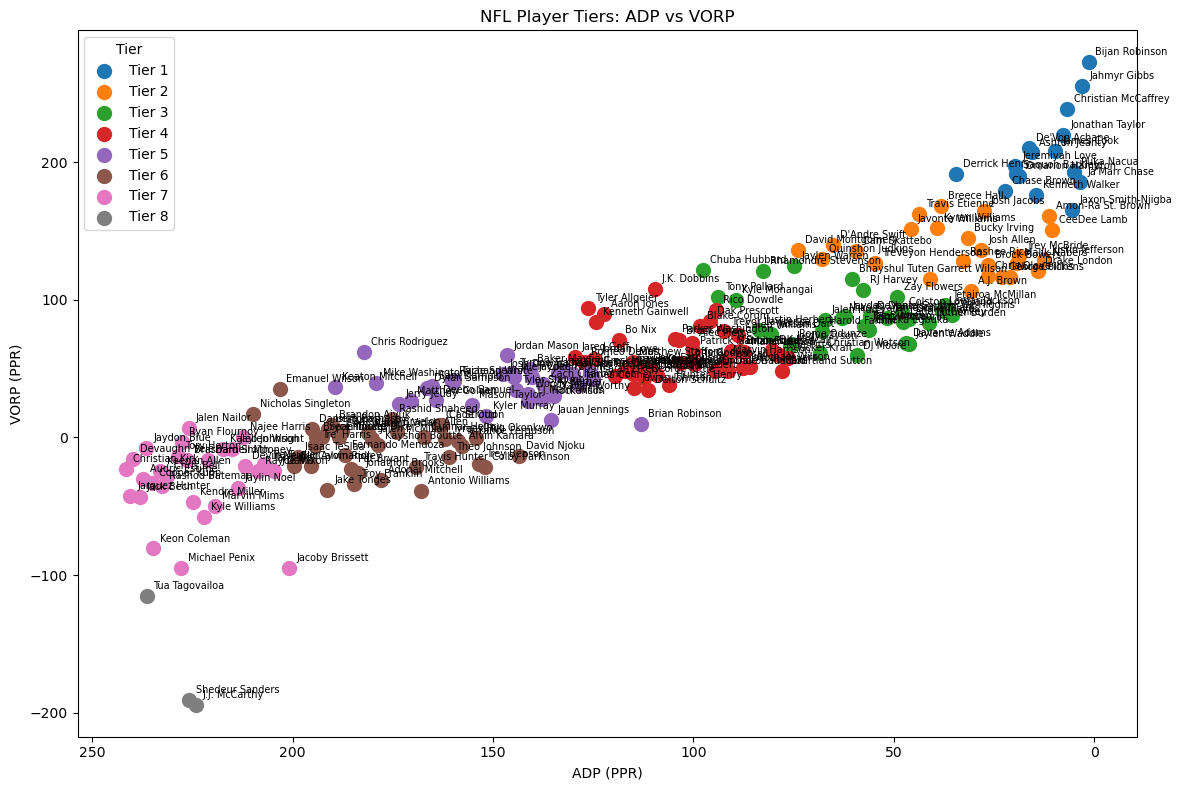

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each tier as a different color
for tier in sorted(df['Tier'].unique()):
    tier_df = df[df['Tier'] == tier]
    ax.scatter(tier_df['adp_ppr'], tier_df['vorp_ppr'], label=f'Tier {tier}', s=100)

# Label each point with player name
for _, row in df.iterrows():
    ax.annotate(row['full_name'], (row['adp_ppr'], row['vorp_ppr']),
                fontsize=7, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('ADP (PPR)')
ax.set_ylabel('VORP (PPR)')
ax.set_title('NFL Player Tiers: ADP vs VORP')
ax.legend(title='Tier')
ax.invert_xaxis()  # Lower ADP = better, so flip x-axis
plt.tight_layout()
plt.show()

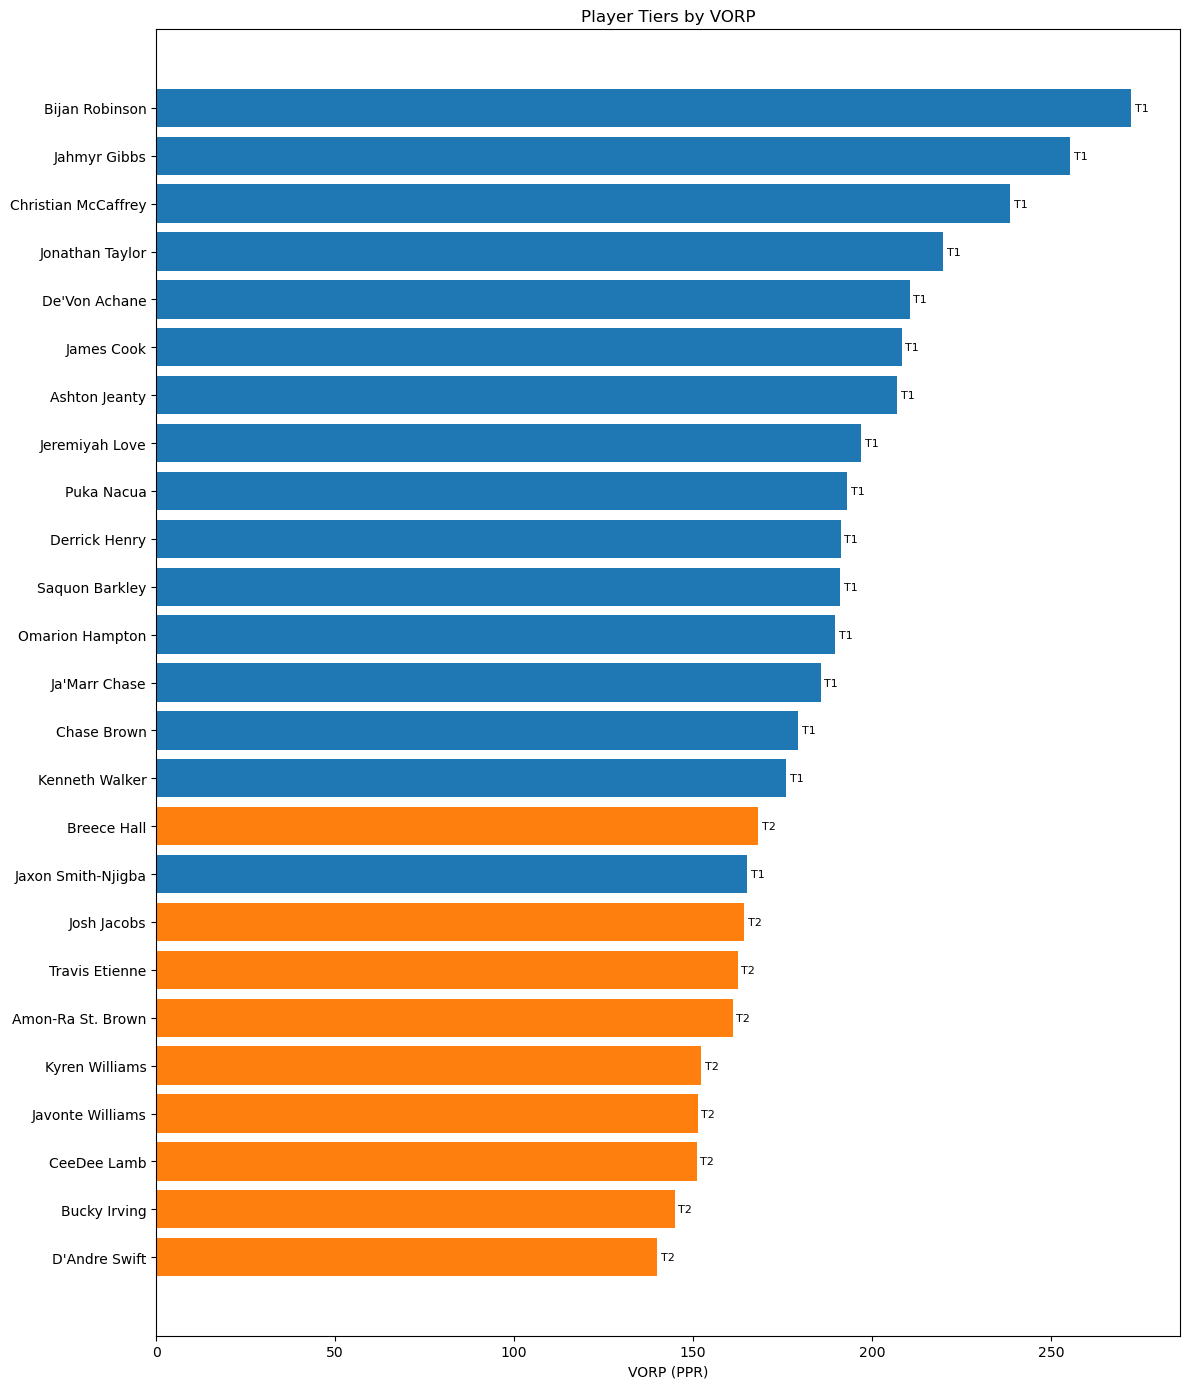

In [35]:
fig, ax = plt.subplots(figsize=(12, 14))

df_sorted = df.sort_values('vorp_ppr', ascending=True).tail(25)
colors = sns.color_palette('tab10', n_colors=df['Tier'].nunique())
tier_colors = df_sorted['Tier'].map(lambda t: colors[int(t)-1])

bars = ax.barh(df_sorted['full_name'], df_sorted['vorp_ppr'], color=tier_colors)

# Add tier labels to bars
for bar, tier in zip(bars, df_sorted['Tier']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'T{int(tier)}', va='center', fontsize=8)

ax.set_xlabel('VORP (PPR)')
ax.set_title('Player Tiers by VORP')
plt.tight_layout()
plt.show()

In [36]:
df[df["full_name"] == "Parker Washington"]

,full_name,position,adp_ppr,vorp_ppr,Round,Tier
96,Parker Washington,WR,104.5,71.2,9.0,4


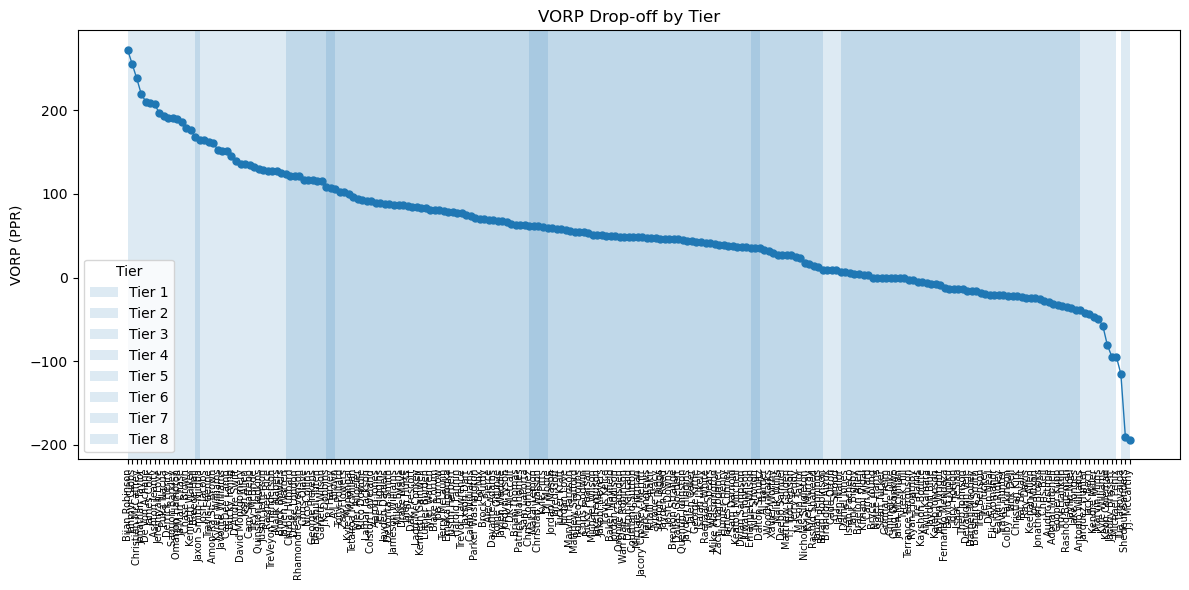

In [37]:
df_sorted = df.sort_values('vorp_ppr', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_sorted.index, df_sorted['vorp_ppr'], marker='o', linewidth=1, markersize=5)

# Shade each tier a different color
for tier in sorted(df_sorted['Tier'].unique()):
    tier_idx = df_sorted[df_sorted['Tier'] == tier].index
    ax.axvspan(tier_idx.min(), tier_idx.max(), alpha=0.15,
               label=f'Tier {int(tier)}')

ax.set_xticks(df_sorted.index)
ax.set_xticklabels(df_sorted['full_name'], rotation=90, fontsize=7)
ax.set_ylabel('VORP (PPR)')
ax.set_title('VORP Drop-off by Tier')
ax.legend(title='Tier')
plt.tight_layout()
plt.show()

In [38]:
# Calculate regression and residual per position
def calc_residuals(group):
    if len(group) < 2:  # need at least 2 players to fit a line
        group['expected_vorp'] = group['vorp_ppr']
        group['value_residual'] = 0
        return group
    
    slope, intercept, r, p, se = stats.linregress(group['adp_ppr'], group['vorp_ppr'])
    group['expected_vorp'] = slope * group['adp_ppr'] + intercept
    group['value_residual'] = group['vorp_ppr'] - group['expected_vorp']
    return group

df = df.groupby('position', group_keys=False).apply(calc_residuals)
# See the most undervalued players per position
df.sort_values('value_residual', ascending=False).tail(20)[
    ['full_name', 'position', 'adp_ppr', 'vorp_ppr', 'value_residual']
]

C:\Users\Aidan\AppData\Local\Temp\ipykernel_37560\3889089027.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('position', group_keys=False).apply(calc_residuals)


,full_name,position,adp_ppr,vorp_ppr,value_residual
28,Bucky Irving,RB,31.6,144.80,-29.468510
171,Troy Franklin,WR,184.7,-33.90,-30.245793
54,DJ Moore,WR,59.3,59.50,-30.450118
42,Davante Adams,WR,46.9,68.70,-30.506048
40,Jaylen Waddle,WR,46.2,68.00,-31.728560
51,Joe Burrow,QB,57.1,80.86,-31.839334
164,Adonai Mitchell,WR,177.9,-31.20,-32.621626
121,James Conner,RB,128.6,37.80,-33.072648
170,Jonathon Brooks,RB,183.6,-26.20,-38.446129
188,Jacoby Brissett,QB,200.9,-94.64,-39.101662


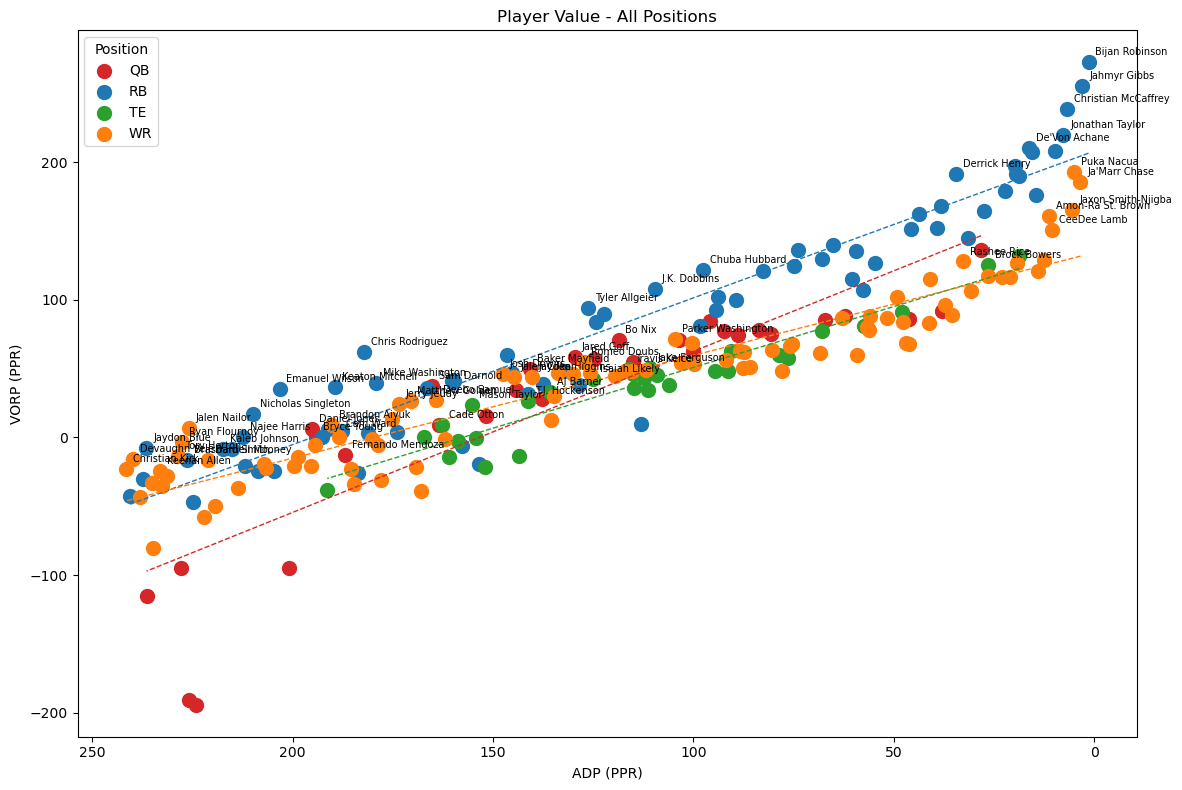

In [39]:
# Set to a position string to filter, or None to show all
position_filter = None  # options: 'RB', 'WR', 'TE', 'QB', or None

# Apply filter
df_plot = df[df['position'] == position_filter] if position_filter else df

fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette('tab10', n_colors=df['position'].nunique())
position_colors = {pos: colors[i] for i, pos in enumerate(df['position'].unique())}

for position, group in df_plot.groupby('position'):
    color = position_colors[position]
    
    ax.scatter(group['adp_ppr'], group['vorp_ppr'],
               label=position, color=color, s=100)
    
    if len(group) >= 2:
        slope, intercept, _, _, _ = stats.linregress(group['adp_ppr'], group['vorp_ppr'])
        x_line = np.linspace(group['adp_ppr'].min(), group['adp_ppr'].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1)

for position, group in df_plot.groupby('position'):
    threshold = group['value_residual'].quantile(0.75)
    for _, row in group[group['value_residual'] > threshold].iterrows():
        ax.annotate(row['full_name'], (row['adp_ppr'], row['vorp_ppr']),
                    fontsize=7, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('ADP (PPR)')
ax.set_ylabel('VORP (PPR)')
ax.set_title(f'Player Value - {position_filter if position_filter else "All Positions"}')
ax.invert_xaxis()
ax.legend(title='Position')
plt.tight_layout()
plt.show()

In [40]:
from scipy import stats
from scipy.optimize import curve_fit
import numpy as np

# --- Fit functions ---
def log_fit(x, a, b):
    return a * np.log(x) + b

def poly_fit(x, a, b, c):
    return a * x**2 + b * x + c

def poly_fit_3(x, a, b, c, d):  # cubic fit
    return a * x**3 + b * x**2 + c * x + d

# --- Calculate residuals for each fit type ---
def calc_residuals_log(group):
    if len(group) < 2:
        group['expected_vorp_log'] = group['vorp_ppr']
        group['residual_log'] = 0
        return group
    try:
        popt, _ = curve_fit(log_fit, group['adp_ppr'], group['vorp_ppr'])
        group['expected_vorp_log'] = log_fit(group['adp_ppr'], *popt)
        group['residual_log'] = group['vorp_ppr'] - group['expected_vorp_log']
    except:
        group['expected_vorp_log'] = group['vorp_ppr']
        group['residual_log'] = 0
    return group

def calc_residuals_poly(group):
    # Only fit the curve on healthy, draftable players
    fit_group = group[
        (group['vorp_ppr'] > 0) & 
        (group['adp_ppr'] <= 150)
    ]
    
    if len(fit_group) < 4:
        group['expected_vorp_poly'] = group['vorp_ppr']
        group['residual_poly'] = 0
        return group
    try:
        popt, _ = curve_fit(poly_fit_3, fit_group['adp_ppr'], fit_group['vorp_ppr'])
        group['expected_vorp_poly'] = poly_fit_3(group['adp_ppr'], *popt)
        group['residual_poly'] = group['vorp_ppr'] - group['expected_vorp_poly']
    except:
        group['expected_vorp_poly'] = group['vorp_ppr']
        group['residual_poly'] = 0
    return group
    
from sklearn.isotonic import IsotonicRegression

def calc_residuals_isotonic(group):
    fit_group = group[group['vorp_ppr'] > 0].sort_values('adp_ppr')
    
    if len(fit_group) < 2:
        group['expected_vorp_iso'] = group['vorp_ppr']
        group['residual_iso'] = 0
        return group
    
    iso = IsotonicRegression(increasing=False, out_of_bounds='clip')
    iso.fit(fit_group['adp_ppr'], fit_group['vorp_ppr'])
    group['expected_vorp_iso'] = iso.predict(group['adp_ppr'])
    group['residual_iso'] = group['vorp_ppr'] - group['expected_vorp_iso']
    return group

df = df.groupby('position', group_keys=False).apply(calc_residuals_isotonic)
df = df.groupby('position', group_keys=False).apply(calc_residuals_poly)
df = df.groupby('position', group_keys=False).apply(calc_residuals_log)
df = df.groupby('position', group_keys=False).apply(calc_residuals_poly)

C:\Users\Aidan\AppData\Local\Temp\ipykernel_37560\3834984724.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('position', group_keys=False).apply(calc_residuals_isotonic)
C:\Users\Aidan\AppData\Local\Temp\ipykernel_37560\3834984724.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('position', group_keys=False).apply(calc_residuals_poly)
C:\Users\Aidan\AppData\Local\Tem

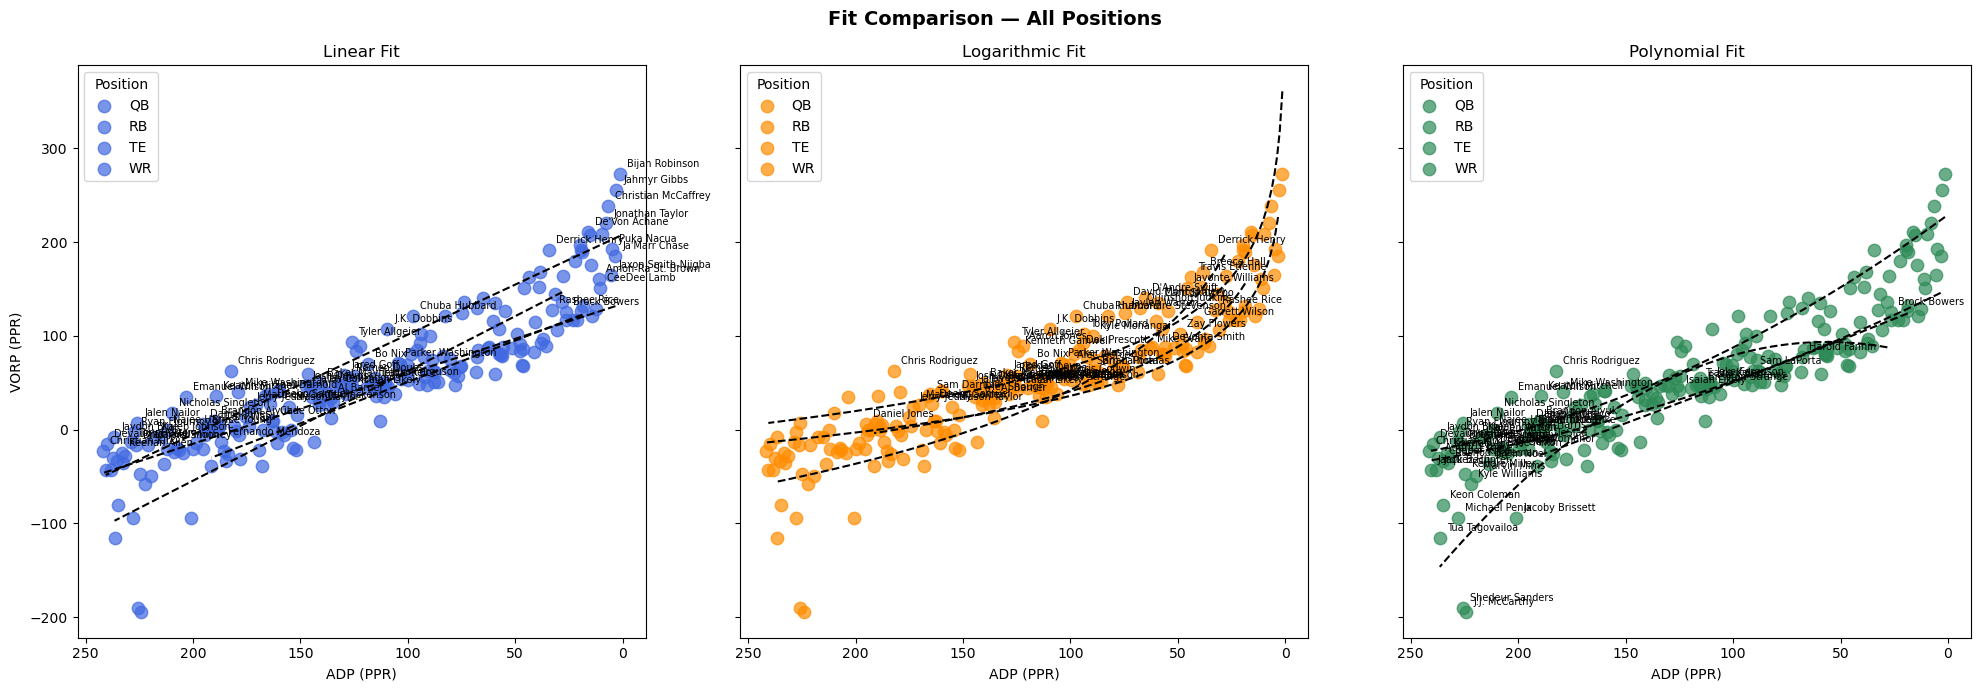

In [42]:
position_filter = ''  # change or set to None for all
df_plot = df[df['position'] == position_filter] if position_filter else df

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fit_configs = [
    ('Linear',      'value_residual',  'royalblue'),
    ('Logarithmic', 'residual_log',    'darkorange'),
    ('Polynomial',  'residual_poly',   'seagreen'),
]

for ax, (fit_name, residual_col, color) in zip(axes, fit_configs):
    for position, group in df_plot.groupby('position'):

        ax.scatter(group['adp_ppr'], group['vorp_ppr'],
                   color=color, s=80, alpha=0.7, label=position)

        x_line = np.linspace(group['adp_ppr'].min(), group['adp_ppr'].max(), 200)

        # Draw the appropriate fit line
        if fit_name == 'Linear':
            slope, intercept, _, _, _ = stats.linregress(group['adp_ppr'], group['vorp_ppr'])
            y_line = slope * x_line + intercept

        elif fit_name == 'Logarithmic':
            try:
                popt, _ = curve_fit(log_fit, group['adp_ppr'], group['vorp_ppr'])
                y_line = log_fit(x_line, *popt)
            except:
                continue

        elif fit_name == 'Polynomial':
            try:
                popt, _ = curve_fit(poly_fit, group['adp_ppr'], group['vorp_ppr'])
                y_line = poly_fit(x_line, *popt)
            except:
                continue

        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)

        # Label top undervalued players for this fit
        threshold = group[residual_col].quantile(0.75)
        for _, row in group[group[residual_col] > threshold].iterrows():
            ax.annotate(row['full_name'], (row['adp_ppr'], row['vorp_ppr']),
                        fontsize=7, xytext=(5, 5), textcoords='offset points')

    ax.set_title(f'{fit_name} Fit')
    ax.set_xlabel('ADP (PPR)')
    ax.invert_xaxis()
    ax.legend(title='Position')

axes[0].set_ylabel('VORP (PPR)')
fig.suptitle(f'Fit Comparison — {position_filter if position_filter else "All Positions"}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
comparison = df[['full_name', 'position', 'adp_ppr', 'vorp_ppr',
                  'value_residual', 'residual_log', 'residual_poly']].copy()

comparison['rank_linear'] = comparison.groupby('position')['value_residual'].rank(ascending=False)
comparison['rank_log']    = comparison.groupby('position')['residual_log'].rank(ascending=False)
comparison['rank_poly']   = comparison.groupby('position')['residual_poly'].rank(ascending=False)

# Players whose rank shifts the most between linear and log
comparison['rank_shift_poly'] = (comparison['rank_linear'] - comparison['rank_poly']).abs()

print("=== Biggest rank changes: Linear vs Cubic Poly ===")
print(comparison.sort_values('rank_shift_poly', ascending=False).head(15)[
    ['full_name', 'position', 'adp_ppr', 'vorp_ppr',
     'rank_linear', 'rank_poly', 'rank_shift_poly']
])

=== Biggest rank changes: Linear vs Cubic Poly ===
               full_name position  adp_ppr  vorp_ppr  rank_linear  rank_poly  \
214         Keon Coleman       WR    234.8     -80.7         88.0       11.0   
202        Kyle Williams       WR    222.1     -57.7         80.0       13.0   
200          Marvin Mims       WR    219.5     -49.6         76.0       14.0   
4     Jaxon Smith-Njigba       WR      5.4     165.1          5.0       65.0   
8            CeeDee Lamb       WR     10.6     151.0          8.0       62.0   
197          Jaylin Noel       WR    213.7     -36.6         67.0       15.0   
204        Kendre Miller       RB    224.8     -46.9         56.0        5.0   
10      Justin Jefferson       WR     12.4     128.6         36.0       84.0   
170      Jonathon Brooks       RB    183.6     -26.2         67.0       22.0   
6        Jonathan Taylor       RB      7.7     219.8         11.0       55.0   
190            Joe Mixon       RB    204.6     -24.6         54.0    